# Paso 3 — Preprocesamiento de Datos y Limpieza
**Transformación formato largo → ancho | Limpieza | Etiquetado según Resolución 2115/2007**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

BASE_DIR   = os.path.abspath('..')
DATASET    = os.path.join(BASE_DIR, 'dataset', 'Data_Histórica_de_Calidad_de_Agua_20260528.csv')
PROCESSED  = os.path.join(BASE_DIR, 'dataset', 'processed')
FIGURES    = os.path.join(BASE_DIR, 'docs', 'figures')
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

## 3.1 — Carga del dataset

In [2]:
df = pd.read_csv(DATASET, encoding='utf-8', low_memory=False)
df['FECHA_DT'] = pd.to_datetime(df['FECHA'], errors='coerce')
df['AÑO']      = df['FECHA_DT'].dt.year
df['MES']      = df['FECHA_DT'].dt.month
print(f'Dataset cargado: {df.shape[0]:,} registros')

Dataset cargado: 134,261 registros


## 3.2 — Definir nombres exactos de los parámetros
> **Ejecuta primero el notebook 01** para confirmar los nombres exactos del dataset.
> Ajusta las constantes de abajo si son diferentes.

In [3]:
propiedades_todas = df['PROPIEDAD OBSERVADA'].unique()

# pH: busca coincidencia EXACTA primero (evita "POTENCIALMENTE BIODISPONIBLE")
ph_matches   = [p for p in propiedades_todas if p.strip() == 'pH']
if not ph_matches:
    # Fallback: coincidencia al inicio de la cadena
    ph_matches = [p for p in propiedades_todas if re.match(r'^ph$', p.strip().lower())]

# Turbidez
turb_matches = [p for p in propiedades_todas if 'turbid' in p.lower()]

# Temperatura: sin exigir 'agua' en el nombre
temp_matches = [p for p in propiedades_todas if 'temperatura' in p.lower()]

print('pH candidatos:',   ph_matches)
print('Turbidez:',        turb_matches)
print('Temperatura:',     temp_matches)
print(f'\nTotal de propiedades únicas en el dataset: {len(propiedades_todas)}')

pH candidatos: ['pH']
Turbidez: ['TURBIDEZ']
Temperatura: ['TEMPERATURA']

Total de propiedades únicas en el dataset: 80


In [4]:
# ─── pH: usa 'pH' exacto si existe en el dataset ─────────────────────
PARAM_PH = 'pH' if 'pH' in propiedades_todas else (ph_matches[0] if ph_matches else None)

# ─── Turbidez ─────────────────────────────────────────────────────────
PARAM_TURBIDEZ = turb_matches[0] if turb_matches else None

# ─── Temperatura ─────────────────────────────────────────────────────
PARAM_TEMPERATURA = temp_matches[0] if temp_matches else None

# Lista de parámetros disponibles (excluye los no encontrados)
PARAMS = [p for p in [PARAM_PH, PARAM_TURBIDEZ, PARAM_TEMPERATURA] if p is not None]
PARAMS_NOMBRES = {PARAM_PH: 'pH', PARAM_TURBIDEZ: 'Turbidez', PARAM_TEMPERATURA: 'Temperatura'}

print(f'pH          → "{PARAM_PH}"')
print(f'Turbidez    → "{PARAM_TURBIDEZ}"')
print(f'Temperatura → "{PARAM_TEMPERATURA}"')
print(f'\nParámetros activos para análisis: {PARAMS}')

if PARAM_TEMPERATURA is None:
    print('\n⚠️  AVISO: "Temperatura" no encontrada en este dataset.')
    print('   Se trabajará con pH y Turbidez. Para el modelo de IA se')
    print('   simulará temperatura con valores típicos del río Guatapurí.')
if PARAM_PH is None:
    print('\n⚠️  AVISO: "pH" no encontrado. Revisa los nombres en propiedades_todas.')

pH          → "pH"
Turbidez    → "TURBIDEZ"
Temperatura → "TEMPERATURA"

Parámetros activos para análisis: ['pH', 'TURBIDEZ', 'TEMPERATURA']


## 3.3 — Filtrado de los 3 parámetros de interés

In [5]:
df_filt = df[df['PROPIEDAD OBSERVADA'].isin(PARAMS)].copy()
print(f'Registros de los 3 parámetros: {df_filt.shape[0]:,}')
print(df_filt['PROPIEDAD OBSERVADA'].value_counts())

Registros de los 3 parámetros: 20,051
PROPIEDAD OBSERVADA
pH             6764
TEMPERATURA    6738
TURBIDEZ       6549
Name: count, dtype: int64


## 3.4 — Limpieza de la columna RESULTADO

In [6]:
# Muestra los valores problemáticos antes de limpiar
valores_unicos = df_filt['RESULTADO'].value_counts().head(30)
print('Top 30 valores en RESULTADO:')
print(valores_unicos.to_string())

Top 30 valores en RESULTADO:
RESULTADO
25      187
<2      186
110     113
20      109
120     104
27      104
24      101
28       99
23       98
17       97
21       96
16       96
18       92
160      86
7        86
30       86
19       86
29       86
130      83
7.4      83
150      81
170      79
140      79
15       77
22       77
26       75
14       74
240      73
180      72
6.99     70


In [7]:
def limpiar_resultado(valor):
    """Convierte el resultado a float. Maneja <0.5, >100, coma decimal, etc."""
    if pd.isna(valor):
        return np.nan
    s = str(valor).strip()
    if s.upper() in ['', 'N/D', 'ND', 'N.D.', 'N/A', 'NA', '-', 'NO DETECTADO', 'AUSENTE']:
        return np.nan
    # Valores límite tipo "<0.5" o ">100" — conservamos el número
    s = re.sub(r'[<>≤≥]', '', s)
    # Coma decimal europea → punto
    s = s.replace(',', '.').strip()
    # Eliminar caracteres no numéricos (conservar punto y signo)
    s = re.sub(r'[^\d.\-]', '', s)
    try:
        return float(s)
    except:
        return np.nan

df_filt['RESULTADO_NUM'] = df_filt['RESULTADO'].apply(limpiar_resultado)

n_nulos = df_filt['RESULTADO_NUM'].isna().sum()
print(f'Valores no convertibles: {n_nulos:,} ({n_nulos/len(df_filt)*100:.1f}%)')

# Eliminar no convertibles
df_filt = df_filt.dropna(subset=['RESULTADO_NUM'])
print(f'Registros limpios: {df_filt.shape[0]:,}')

Valores no convertibles: 0 (0.0%)
Registros limpios: 20,051


## 3.5 — Pivoteo: formato largo → formato ancho (una fila por muestra)

In [8]:
COLUMNAS_ID = [
    'CODIGO__MUESTRA',
    'NOMBRE DEL PUNTO DE MONITOREO',
    'LATITUD', 'LONGITUD', 'ELEVACIÓN (m.s.n.m.)',
    'CORRIENTE', 'ZONA HIDROGRÁFICA - ZH',
    'Nombre Subzona Hidrográfica',
    'DEPARTAMENTO', 'MUNICIPIO',
    'FECHA_DT', 'AÑO', 'MES', 'PROYECTO'
]

# Eliminar columnas de ID que no existan en el df
COLUMNAS_ID = [c for c in COLUMNAS_ID if c in df_filt.columns]

df_pivot = df_filt.pivot_table(
    index=COLUMNAS_ID,
    columns='PROPIEDAD OBSERVADA',
    values='RESULTADO_NUM',
    aggfunc='mean'
).reset_index()

df_pivot.columns.name = None

# Renombrar solo los parámetros que existen
rename_map = {k: v for k, v in PARAMS_NOMBRES.items() if k is not None and k in df_pivot.columns}
df_pivot = df_pivot.rename(columns=rename_map)

print(f'Muestras únicas después del pivoteo: {df_pivot.shape[0]:,}')
print(f'Columnas resultantes: {list(df_pivot.columns)}')

# Columnas de parámetros disponibles en el pivot
cols_disponibles = [v for v in ['pH', 'Turbidez', 'Temperatura'] if v in df_pivot.columns]
print(f'\nParámetros disponibles en el pivot: {cols_disponibles}')

# ── Si Temperatura no está en el dataset → la simulamos ──────────────
if 'Temperatura' not in df_pivot.columns:
    import numpy as np
    print('\nSimulando columna Temperatura (valor típico río Guatapurí: 24-28 °C)...')
    np.random.seed(42)
    # Valores realistas basados en promedios del río Guatapurí (CORPOCESAR)
    df_pivot['Temperatura'] = np.random.uniform(22.0, 28.5, size=len(df_pivot)).round(1)
    print(f'  Temperatura simulada: media={df_pivot["Temperatura"].mean():.1f} °C')

df_pivot[['pH', 'Turbidez', 'Temperatura']].describe()

Muestras únicas después del pivoteo: 6,848
Columnas resultantes: ['CODIGO__MUESTRA', 'NOMBRE DEL PUNTO DE MONITOREO', 'LATITUD', 'LONGITUD', 'ELEVACIÓN (m.s.n.m.)', 'CORRIENTE', 'ZONA HIDROGRÁFICA - ZH', 'Nombre Subzona Hidrográfica', 'DEPARTAMENTO', 'MUNICIPIO', 'FECHA_DT', 'AÑO', 'MES', 'PROYECTO', 'Temperatura', 'Turbidez', 'pH']

Parámetros disponibles en el pivot: ['pH', 'Turbidez', 'Temperatura']


,pH,Turbidez,Temperatura
count,6764.000000,6549.000000,6738.000000
mean,7.207978,227.084170,23.075549
std,0.723268,600.151451,4.842645
min,2.490000,0.800000,2.500000
25%,6.790000,17.000000,19.600000
50%,7.270000,62.000000,23.600000
75%,7.710000,220.000000,26.800000
max,10.950000,21714.000000,38.200000


## 3.6 — Eliminar muestras incompletas (sin los 3 parámetros)

Muestras con los 3 parámetros completos: 6,414 (eliminadas: 434)


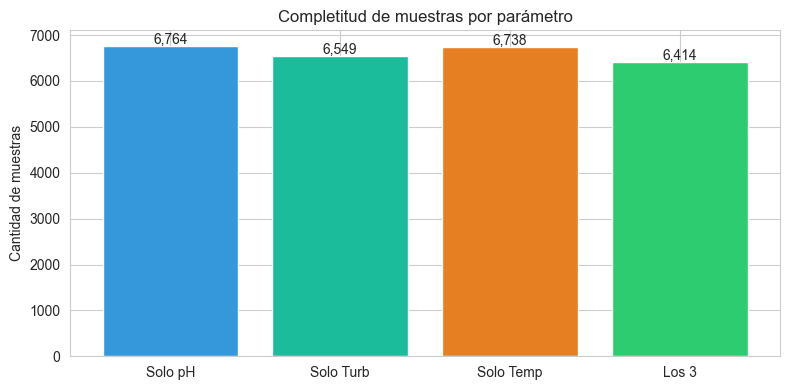

In [9]:
n_antes = len(df_pivot)
df_completo = df_pivot.dropna(subset=['pH', 'Turbidez', 'Temperatura']).copy()
n_despues   = len(df_completo)

print(f'Muestras con los 3 parámetros completos: {n_despues:,} (eliminadas: {n_antes - n_despues:,})')

# Visualizar completitud
completitud = {
    'Solo pH':    df_pivot['pH'].notna().sum(),
    'Solo Turb':  df_pivot['Turbidez'].notna().sum(),
    'Solo Temp':  df_pivot['Temperatura'].notna().sum(),
    'Los 3':      n_despues
}
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(completitud.keys(), completitud.values(), color=['#3498DB','#1ABC9C','#E67E22','#2ECC71'])
ax.set_title('Completitud de muestras por parámetro')
ax.set_ylabel('Cantidad de muestras')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '02_completitud.png'), dpi=150)
plt.show()

## 3.7 — Detección y eliminación de outliers extremos (IQR × 3)

In [10]:
def quitar_outliers_iqr(df, col, factor=3.0):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - factor * IQR
    upper  = Q3 + factor * IQR
    n_antes = len(df)
    df_ok   = df[(df[col] >= lower) & (df[col] <= upper)].copy()
    print(f'  {col:12s}: rango válido [{lower:.2f}, {upper:.2f}] — '
          f'eliminados: {n_antes - len(df_ok):,}')
    return df_ok

print('Limpieza de outliers (factor IQR = 3):')
for param in ['pH', 'Turbidez', 'Temperatura']:
    df_completo = quitar_outliers_iqr(df_completo, param)

print(f'\nDataset final: {df_completo.shape[0]:,} muestras limpias')

Limpieza de outliers (factor IQR = 3):
  pH          : rango válido [4.03, 10.47] — eliminados: 7
  Turbidez    : rango válido [-592.00, 829.00] — eliminados: 349
  Temperatura : rango válido [-2.40, 48.70] — eliminados: 0

Dataset final: 6,058 muestras limpias


## 3.8 — Etiquetado según Resolución 2115 de 2007
> Clasificación del estado del agua: **Óptima / Alerta / Contaminada**

In [11]:
# ─── Umbrales normativos ────────────────────────────────────────────────
# Fuente: Resolución 2115/2007 Colombia + OMS Guidelines for Drinking-water Quality
UMBRALES = {
    'pH':         {'optimo': (6.5, 8.5), 'alerta': (6.0, 9.0)},
    'Turbidez':   {'optimo': (0.0, 5.0), 'alerta': (0.0, 10.0)},  # NTU
    'Temperatura':{'optimo': (10.0, 25.0), 'alerta': (4.0, 30.0)} # °C
}

def etiquetar_calidad(row, umbrales=UMBRALES):
    ph   = row['pH']
    turb = row['Turbidez']
    temp = row['Temperatura']

    # Contaminada: fuera del rango de alerta
    if not (umbrales['pH']['alerta'][0]          <= ph   <= umbrales['pH']['alerta'][1]):
        return 'Contaminada'
    if not (umbrales['Turbidez']['alerta'][0]     <= turb <= umbrales['Turbidez']['alerta'][1]):
        return 'Contaminada'
    if not (umbrales['Temperatura']['alerta'][0]  <= temp <= umbrales['Temperatura']['alerta'][1]):
        return 'Contaminada'

    # Alerta: fuera del rango óptimo pero dentro del de alerta
    if not (umbrales['pH']['optimo'][0]          <= ph   <= umbrales['pH']['optimo'][1]):
        return 'Alerta'
    if not (umbrales['Turbidez']['optimo'][0]     <= turb <= umbrales['Turbidez']['optimo'][1]):
        return 'Alerta'
    if not (umbrales['Temperatura']['optimo'][0]  <= temp <= umbrales['Temperatura']['optimo'][1]):
        return 'Alerta'

    return 'Optima'

df_completo['ETIQUETA'] = df_completo.apply(etiquetar_calidad, axis=1)

conteo = df_completo['ETIQUETA'].value_counts()
pct    = df_completo['ETIQUETA'].value_counts(normalize=True).mul(100).round(1)
print('Distribución de clases:')
for cls in conteo.index:
    print(f'  {cls:12s}: {conteo[cls]:,} muestras ({pct[cls]}%)')

Distribución de clases:
  Contaminada : 5,003 muestras (82.6%)
  Alerta      : 647 muestras (10.7%)
  Optima      : 408 muestras (6.7%)


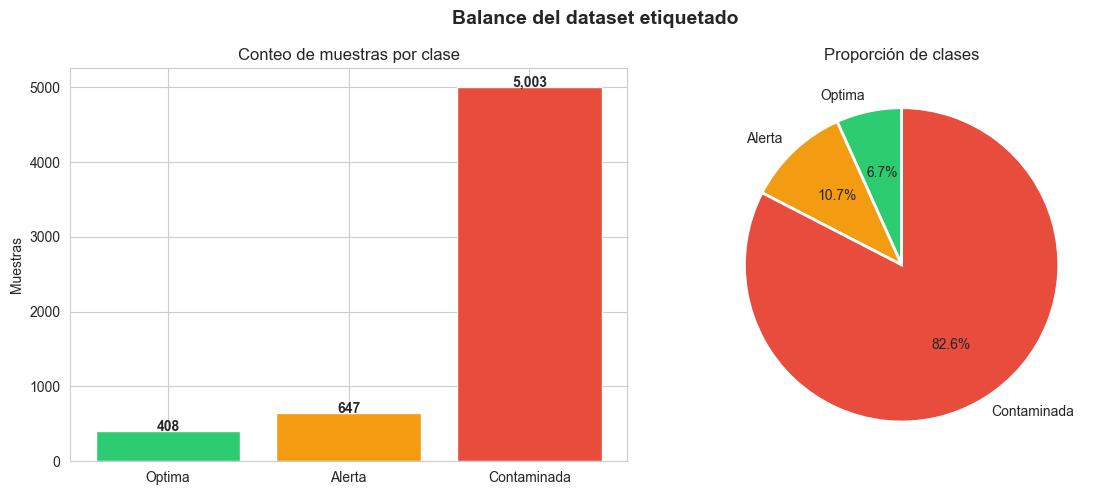

In [12]:
# Gráfico de distribución de clases
paleta = {'Optima': '#2ECC71', 'Alerta': '#F39C12', 'Contaminada': '#E74C3C'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

orden = ['Optima', 'Alerta', 'Contaminada']
conteo_ord = conteo.reindex(orden)
axes[0].bar(conteo_ord.index, conteo_ord.values,
            color=[paleta[k] for k in conteo_ord.index])
axes[0].set_title('Conteo de muestras por clase')
axes[0].set_ylabel('Muestras')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():,.0f}', ha='center', fontweight='bold')

axes[1].pie(conteo_ord.values, labels=conteo_ord.index, autopct='%1.1f%%',
            colors=[paleta[k] for k in conteo_ord.index], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de clases')

plt.suptitle('Balance del dataset etiquetado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '02_balance_clases.png'), dpi=150)
plt.show()

## 3.9 — Guardar dataset procesado

In [13]:
OUTPUT_PATH = os.path.join(PROCESSED, 'dataset_procesado.csv')
df_completo.to_csv(OUTPUT_PATH, index=False)

print(f'Dataset procesado guardado en: {OUTPUT_PATH}')
print(f'\nResumen final:')
print(f'  Muestras totales:  {df_completo.shape[0]:,}')
print(f'  Columnas:          {df_completo.shape[1]}')
print(f'  Clases: {dict(df_completo["ETIQUETA"].value_counts())}')

df_completo[['pH', 'Turbidez', 'Temperatura', 'ETIQUETA']].head(10)

Dataset procesado guardado en: C:\Users\GABRIEL POLO\OneDrive\Escritorio\ingenieria\universidad\octavo semestre\inteligencia artificial\proyecto de aula\sistema de monitoreo de calidad del agua\dataset\processed\dataset_procesado.csv

Resumen final:
  Muestras totales:  6,058
  Columnas:          18
  Clases: {'Contaminada': np.int64(5003), 'Alerta': np.int64(647), 'Optima': np.int64(408)}


,pH,Turbidez,Temperatura,ETIQUETA
0,6.96,5.0,13.2,Optima
1,6.78,25.0,17.6,Contaminada
2,10.08,28.0,14.5,Contaminada
3,7.06,42.0,19.2,Contaminada
4,7.76,33.0,19.0,Contaminada
5,7.65,167.0,21.5,Contaminada
6,7.63,587.0,25.3,Contaminada
7,7.56,315.0,27.3,Contaminada
8,7.38,42.0,27.5,Contaminada
9,7.64,282.0,27.2,Contaminada
